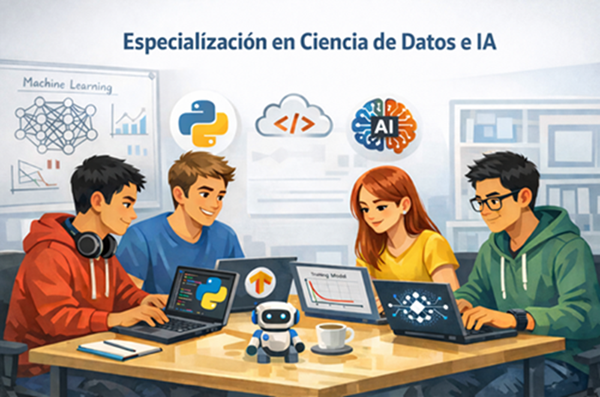

# MLOps - Parte I
## Análisis Exploratorio de Datos (EDA) del Secondary Mushroom Dataset

**Curso:** MLOps
**Profesora:** Maria Camila Durango Barrera  
**Dataset:** Secondary Mushroom Dataset  
**Fuente:** UCI Machine Learning Repository  
**Integrantes:** Daniela Gutierrez Garces, Carlos Andrés Morcillo Tapia, Andrés Felipe Lopez, Yessid Alejandro Restrepo Villa  
**Fecha:** 06 de abril de 2026

---


## 1. Introducción

Como parte de la primera entrega del curso de MLOps, este proyecto presenta un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** del **UCI Machine Learning Repository**.

El dataset escogido es una dataset tabular de UCI para clasificación binaria que contiene alrededor de 61 mil observaciones de hongos simulados y 20 variables predictoras. Su objetivo es determinar si un hongo es comestible o venenoso, usando una combinación de variables numéricas y categóricas, lo que lo hace adecuado para análisis exploratorio, preprocesamiento y futuros modelos de machine learning.

En esta primera etapa, el enfoque no está en construir un modelo final de aprendizaje automático, sino en comprender la estructura, la calidad y los principales patrones de los datos. Este análisis servirá como base para etapas posteriores relacionadas con el preprocesamiento, el modelado, la orquestación y el despliegue dentro de un flujo de trabajo de MLOps.


## 2. Objetivo General

Realizar un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** con el fin de comprender su estructura, identificar problemas de calidad de los datos, explorar variables numéricas y categóricas, analizar las relaciones entre las características y generar hallazgos que puedan orientar futuras etapas de aprendizaje automático y MLOps.


## 3. Objetivos Específicos

- Cargar e inspeccionar la estructura del dataset.
- Identificar valores faltantes, duplicados y posibles inconsistencias.
- Describir las variables numéricas y categóricas.
- Visualizar la distribución de la variable objetivo y de las características más relevantes.
- Analizar las correlaciones entre las variables numéricas.
- Extraer hallazgos clave que puedan apoyar futuras decisiones de preprocesamiento y modelado.


## 4. Descripción del Dataset

El **Secondary Mushroom Dataset** fue obtenido del **UCI Machine Learning Repository**.  
Contiene más de sesenta mil observaciones de hongos e incluye tanto variables **continuas** como **categóricas**. La variable objetivo indica si un hongo es **comestible** o **venenoso**.


## 5. Pregunta Orientadora

¿Qué patrones, distribuciones, problemas de calidad de datos y relaciones pueden identificarse en el **Secondary Mushroom Dataset** antes de avanzar hacia las etapas de preprocesamiento y aprendizaje automático?


## 6. Carga de Librerías y del Dataset

En esta sección, importamos las librerías necesarias de Python y cargamos el dataset en un DataFrame de pandas para realizar una inspección inicial.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "secondary_data.csv"
SRC_PATH = PROJECT_ROOT / "src"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Src path:", SRC_PATH)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(DATA_PATH, sep=";")
TARGET_COL = "class"                    # Incluímos el target en el DataFrame para facilitar su análisis

display(df.head())

Project root: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom
Data path: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom\data\secondary_data.csv
Src path: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom\src


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


## 7. Inspección Inicial de los Datos

El propósito de esta sección es comprender la estructura básica del dataset:
- número de filas y columnas,
- nombres de las variables,
- tipos de datos,
- registros de muestra,
- y metadatos generales.


📋 **Variables observadas**

| Variable | Descripción | Tipo de dato |
| --- | --- | --- |
| 🎯 **class** | **Variable objetivo**: clase del hongo (`e` = comestible, `p` = venenoso). | string *(object)* |
| 📏 **cap-diameter** | Diámetro del sombrero del hongo, medido en cm. | float64 |
| 📐 **stem-height** | Altura del tallo del hongo, medida en cm. | float64 |
| 📌 **stem-width** | Ancho del tallo del hongo, medido en mm. | float64 |
| 🍄 **cap-shape** | Forma del sombrero. | string *(object)* |
| 🧩 **cap-surface** | Textura o superficie del sombrero. | string *(object)* |
| 🎨 **cap-color** | Color del sombrero. | string *(object)* |
| 🩸 **does-bruise-or-bleed** | Indica si el hongo se magulla o sangra al manipularlo. | string *(object)* |
| 🌿 **gill-attachment** | Tipo de unión de las laminillas al tallo. | string *(object)* |
| ↔️ **gill-spacing** | Espaciamiento entre las laminillas. | string *(object)* |
| 🌈 **gill-color** | Color de las laminillas. | string *(object)* |
| 🌱 **stem-root** | Tipo de raíz o base del tallo. | string *(object)* |
| 🪵 **stem-surface** | Textura o superficie del tallo. | string *(object)* |
| 🟫 **stem-color** | Color del tallo. | string *(object)* |
| 🧣 **veil-type** | Tipo de velo presente en el hongo. | string *(object)* |
| 🎭 **veil-color** | Color del velo. | string *(object)* |
| 💍 **has-ring** | Indica si el hongo presenta anillo. | string *(object)* |
| 🔘 **ring-type** | Tipo de anillo. | string *(object)* |
| 🌫️ **spore-print-color** | Color de la impresión de esporas. | string *(object)* |
| 🌍 **habitat** | Hábitat donde se encuentra el hongo. | string *(object)* |
| 🍂 **season** | Estación del año en la que aparece el hongo. | string *(object)* |

In [2]:
print("Shape (rows, columns):", df.shape)
print("Column names:", list(df.columns))

display(df.head(10))
display(df.sample(n=min(10, len(df)), random_state=42))

df.info(memory_usage="deep")

df.dtypes

Shape (rows, columns): (61069, 21)
Column names: ['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
11541,e,1.32,c,g,n,f,a,NaN,g,4.41,...,NaN,NaN,g,NaN,NaN,f,f,NaN,l,a
35700,p,4.41,x,h,o,f,a,c,n,4.18,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
55781,e,9.23,o,NaN,n,f,NaN,NaN,w,4.50,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
29303,p,3.16,f,w,n,t,d,c,y,3.13,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,u
46601,e,3.71,x,h,n,f,NaN,c,n,5.85,...,NaN,s,w,NaN,w,f,f,k,d,a
44573,p,8.88,p,y,w,f,NaN,NaN,k,19.23,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
4948,e,7.23,f,NaN,g,f,s,c,u,6.22,...,NaN,NaN,b,NaN,NaN,f,f,NaN,d,a
33350,p,9.87,x,s,y,f,s,NaN,p,8.85,...,NaN,i,n,NaN,NaN,f,f,NaN,d,u
431,p,6.59,x,g,n,f,e,NaN,w,8.58,...,NaN,y,w,u,w,t,p,NaN,d,u
43050,e,8.80,x,s,w,t,e,NaN,g,9.01,...,s,NaN,w,NaN,NaN,t,l,NaN,m,u


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object

## 8. Evaluación de la Calidad de los Datos




Un EDA adecuado requiere evaluar la calidad del dataset antes de realizar un análisis más profundo.  
En esta sección, revisamos:
- valores faltantes,
- filas duplicadas,
- categorías inconsistentes,
- y posibles problemas en el ingreso de datos.

Este paso es importante porque los problemas de calidad de los datos pueden afectar futuras etapas de preprocesamiento y modelado.

**Valores faltantes**

In [3]:
# Análisis exploratorio, como estadísticas descriptivas, distribución de clases, correlaciones

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

display(missing_summary)

,missing_count,missing_percent
veil-type,57892,94.80
spore-print-color,54715,89.60
veil-color,53656,87.86
stem-root,51538,84.39
stem-surface,38124,62.43
gill-spacing,25063,41.04
cap-surface,14120,23.12
gill-attachment,9884,16.18
ring-type,2471,4.05
cap-color,0,0.00


**Resumen de duplicados**

In [4]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

dup_count = df.duplicated().sum()
dup_percent = round((dup_count / len(df)) * 100, 2)

dup_summary = pd.DataFrame({
    "duplicate_rows": [dup_count],
    "duplicate_percent": [dup_percent]
})

display(dup_summary)

,duplicate_rows,duplicate_percent
0,146,0.24


**Columnas numéricas y categóricas**

In [5]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns (incl. target):", categorical_cols)

Numerical columns: ['cap-diameter', 'stem-height', 'stem-width']
Categorical columns (incl. target): ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


**Comprobación de Target y columnas con cardinalidad muy alta o tokens extraños**

In [6]:
print("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")

Target value counts:
class
p    33888
e    27181
Name: count, dtype: int64
No rare categorical levels found under 0.1%.


## 9. Análisis Descriptivo

Para las **variables numéricas**, analizamos:
- cantidad de datos,
- media,
- mediana,
- desviación estándar,
- valores mínimo y máximo,
- y posibles valores atípicos.

Para las **variables categóricas**, analizamos:
- las categorías más frecuentes,
- el balance entre categorías,
- y posibles etiquetas poco frecuentes.


In [7]:
# pendiprint("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")


class
p    33888
e    27181
Name: count, dtype: int64
No rare categorical levels found under 0.1%.


In [8]:
# ============================
# Resumen descriptivo de variables numéricas
# ============================
if len(numerical_cols) > 0:
    num_summary = df[numerical_cols].describe().T
    num_summary["median"] = df[numerical_cols].median()
    num_summary["missing_count"] = df[numerical_cols].isnull().sum()
    num_summary["missing_percent"] = (df[numerical_cols].isnull().mean() * 100).round(2)
    display(num_summary)
else:
    print("No numerical columns found.")

# ============================
# Medianas
# ============================
if len(numerical_cols) > 0:
    medians = df[numerical_cols].median()
    display(medians.to_frame("median"))
else:
    print("No numerical columns available for median calculation.")

# ============================
# Modas de variables categóricas + target
# ============================
cat_feats = [c for c in categorical_cols if c != TARGET_COL]
mode_cols = cat_feats + [TARGET_COL] if TARGET_COL in df.columns else cat_feats

if len(mode_cols) > 0:
    mode_dict = {}
    for col in mode_cols:
        col_mode = df[col].mode(dropna=True)
        mode_dict[col] = col_mode.iloc[0] if not col_mode.empty else np.nan

    modes = pd.DataFrame.from_dict(mode_dict, orient="index", columns=["mode"])
    display(modes)
else:
    print("No categorical columns found for mode calculation.")

# ============================
# Resumen de variables categóricas
# ============================
cat_summary_rows = []

for col in cat_feats:
    top_categories = df[col].value_counts(dropna=False).head(5).to_dict()
    cat_summary_rows.append({
        "column": col,
        "n_unique": df[col].nunique(dropna=False),
        "top_categories": str(top_categories)
    })

cat_summary_df = pd.DataFrame(cat_summary_rows)

if not cat_summary_df.empty:
    display(cat_summary_df)
else:
    print("No categorical feature summary available.")

# ============================
# Resumen de outliers usando IQR
# ============================
iqr_outlier_rows = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_percent = round((outlier_count / len(df)) * 100, 2)

    iqr_outlier_rows.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_percent
    })

iqr_outliers = pd.DataFrame(iqr_outlier_rows)

if not iqr_outliers.empty:
    display(iqr_outliers)
else:
    print("No numerical columns available for IQR outlier analysis.")

,count,mean,std,min,25%,50%,75%,max,median,missing_count,missing_percent
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34,5.86,0,0.0
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92,5.95,0,0.0
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91,10.19,0,0.0


,median
cap-diameter,5.86
stem-height,5.95
stem-width,10.19


,mode
cap-shape,x
cap-surface,t
cap-color,n
does-bruise-or-bleed,f
gill-attachment,a
gill-spacing,c
gill-color,w
stem-root,b
stem-surface,s
stem-color,w


,column,n_unique,top_categories
0,cap-shape,7,"{'x': 26934, 'f': 13404, 's': 7164, 'b': 5694,..."
1,cap-surface,12,"{nan: 14120, 't': 8196, 's': 7608, 'y': 6341, ..."
2,cap-color,12,"{'n': 24218, 'y': 8543, 'w': 7666, 'g': 4420, ..."
3,does-bruise-or-bleed,2,"{'f': 50479, 't': 10590}"
4,gill-attachment,8,"{'a': 12698, 'd': 10247, nan: 9884, 'x': 7413,..."
5,gill-spacing,4,"{nan: 25063, 'c': 24710, 'd': 7766, 'f': 3530}"
6,gill-color,12,"{'w': 18521, 'n': 9645, 'y': 9546, 'p': 5983, ..."
7,stem-root,6,"{nan: 51538, 's': 3177, 'b': 3177, 'r': 1412, ..."
8,stem-surface,9,"{nan: 38124, 's': 6025, 'y': 4940, 'i': 4396, ..."
9,stem-color,13,"{'w': 22926, 'n': 18063, 'y': 7865, 'g': 2626,..."


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,cap-diameter,3.48,8.54,5.06,-4.11,16.13,2400,3.93
1,stem-height,4.64,7.74,3.10,-0.01,12.39,3169,5.19
2,stem-width,5.21,16.57,11.36,-11.83,33.61,1967,3.22


## 10. Análisis de la Variable Objetivo

Dado que la futura tarea de aprendizaje automático (Parte II) será de clasificación binaria, es importante comprender la distribución de la clase objetivo.  
En esta sección, se explora si la variable objetivo está balanceada o desbalanceada y qué implicaciones puede tener esto para futuros procesos de modelado.


,count,percent
class,,
p,33888,55.49
e,27181,44.51


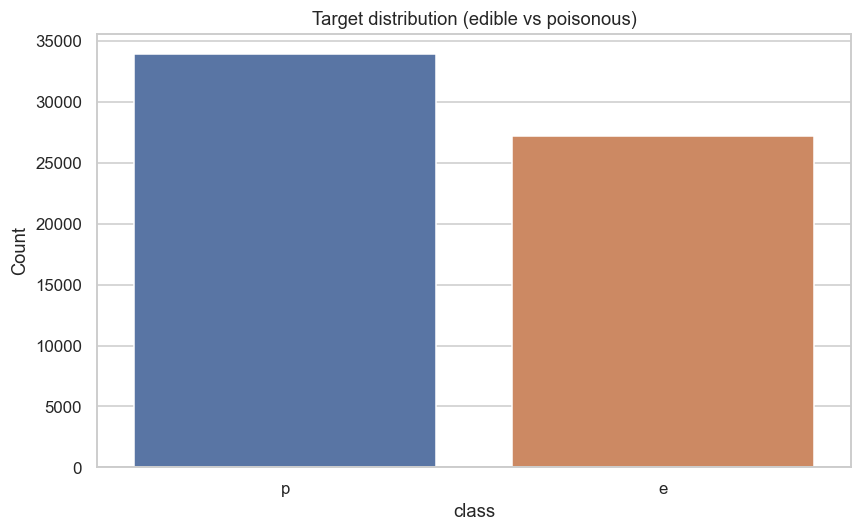

In [9]:
import warnings
warnings.filterwarnings("ignore")

vc = df[TARGET_COL].value_counts(dropna=False)
vp = df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

target_balance = pd.DataFrame({
    "count": vc,
    "percent": vp.round(2)
})

display(target_balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COL, palette=["#4C72B0", "#DD8452"])
plt.title("Target distribution (edible vs poisonous)")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 11. Análisis Visual Exploratorio

Las visualizaciones ayudan a revelar patrones que son difíciles de identificar únicamente con tablas.

En esta sección, utilizamos:
- gráficos de barras para variables categóricas,
- histogramas para variables numéricas,
- diagramas de caja para detectar dispersión y valores atípicos,
- y gráficos comparativos agrupados por la clase objetivo.


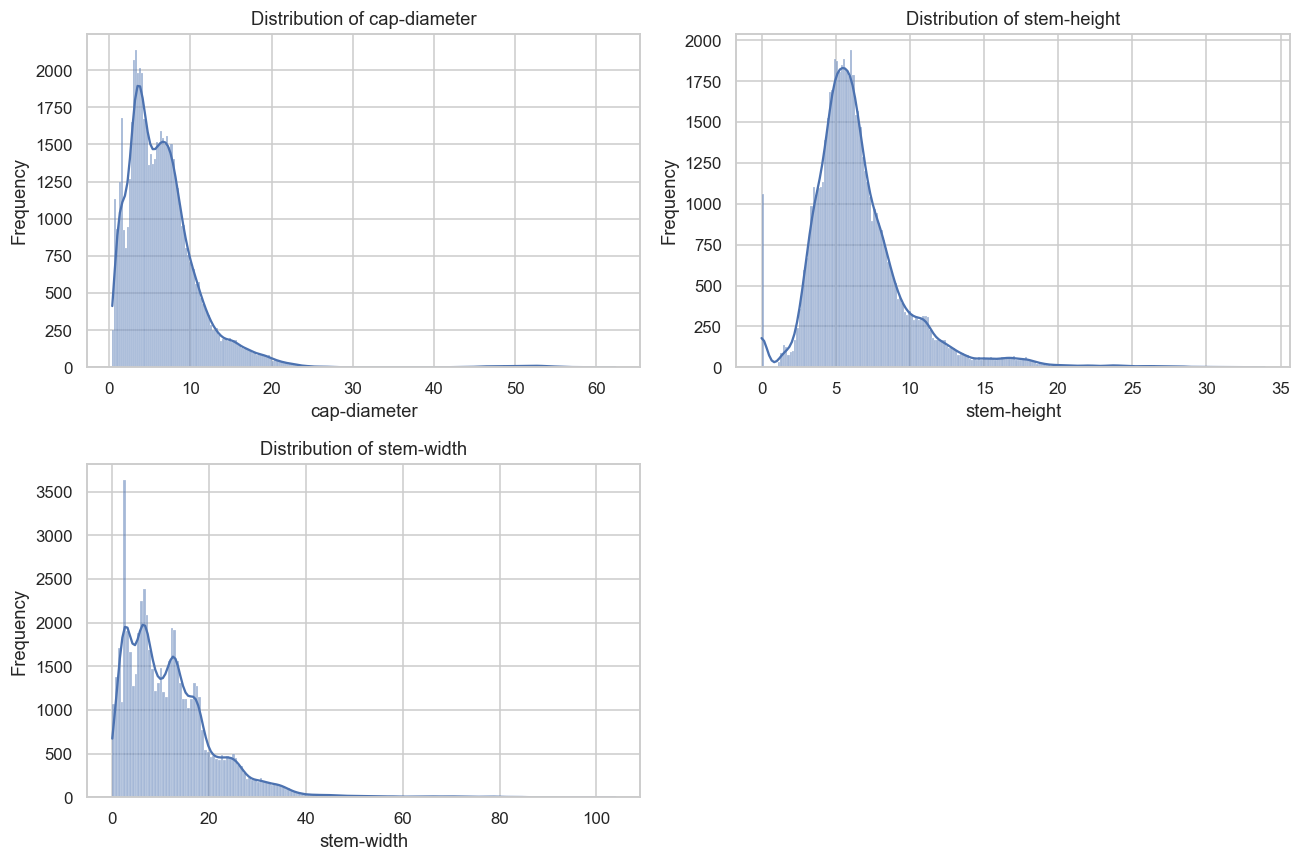

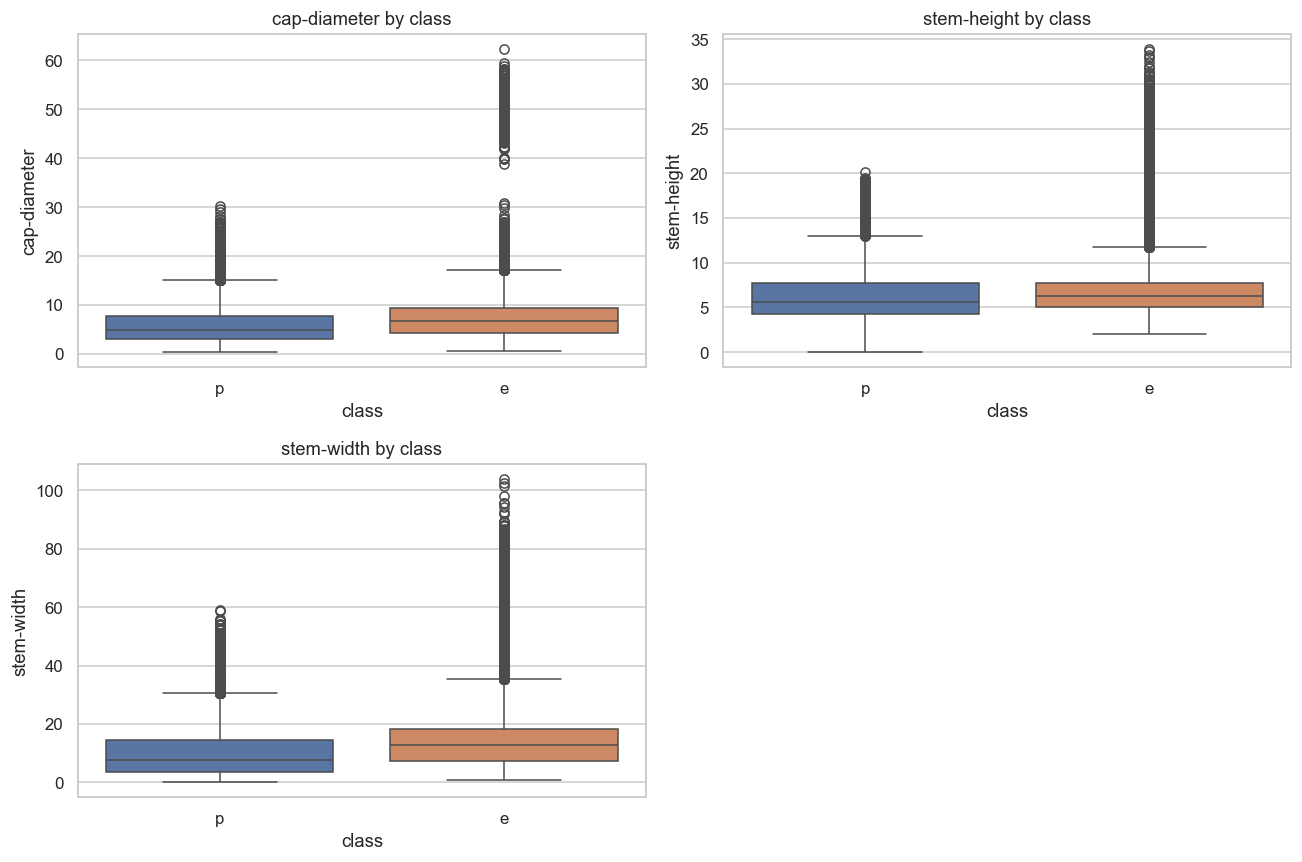

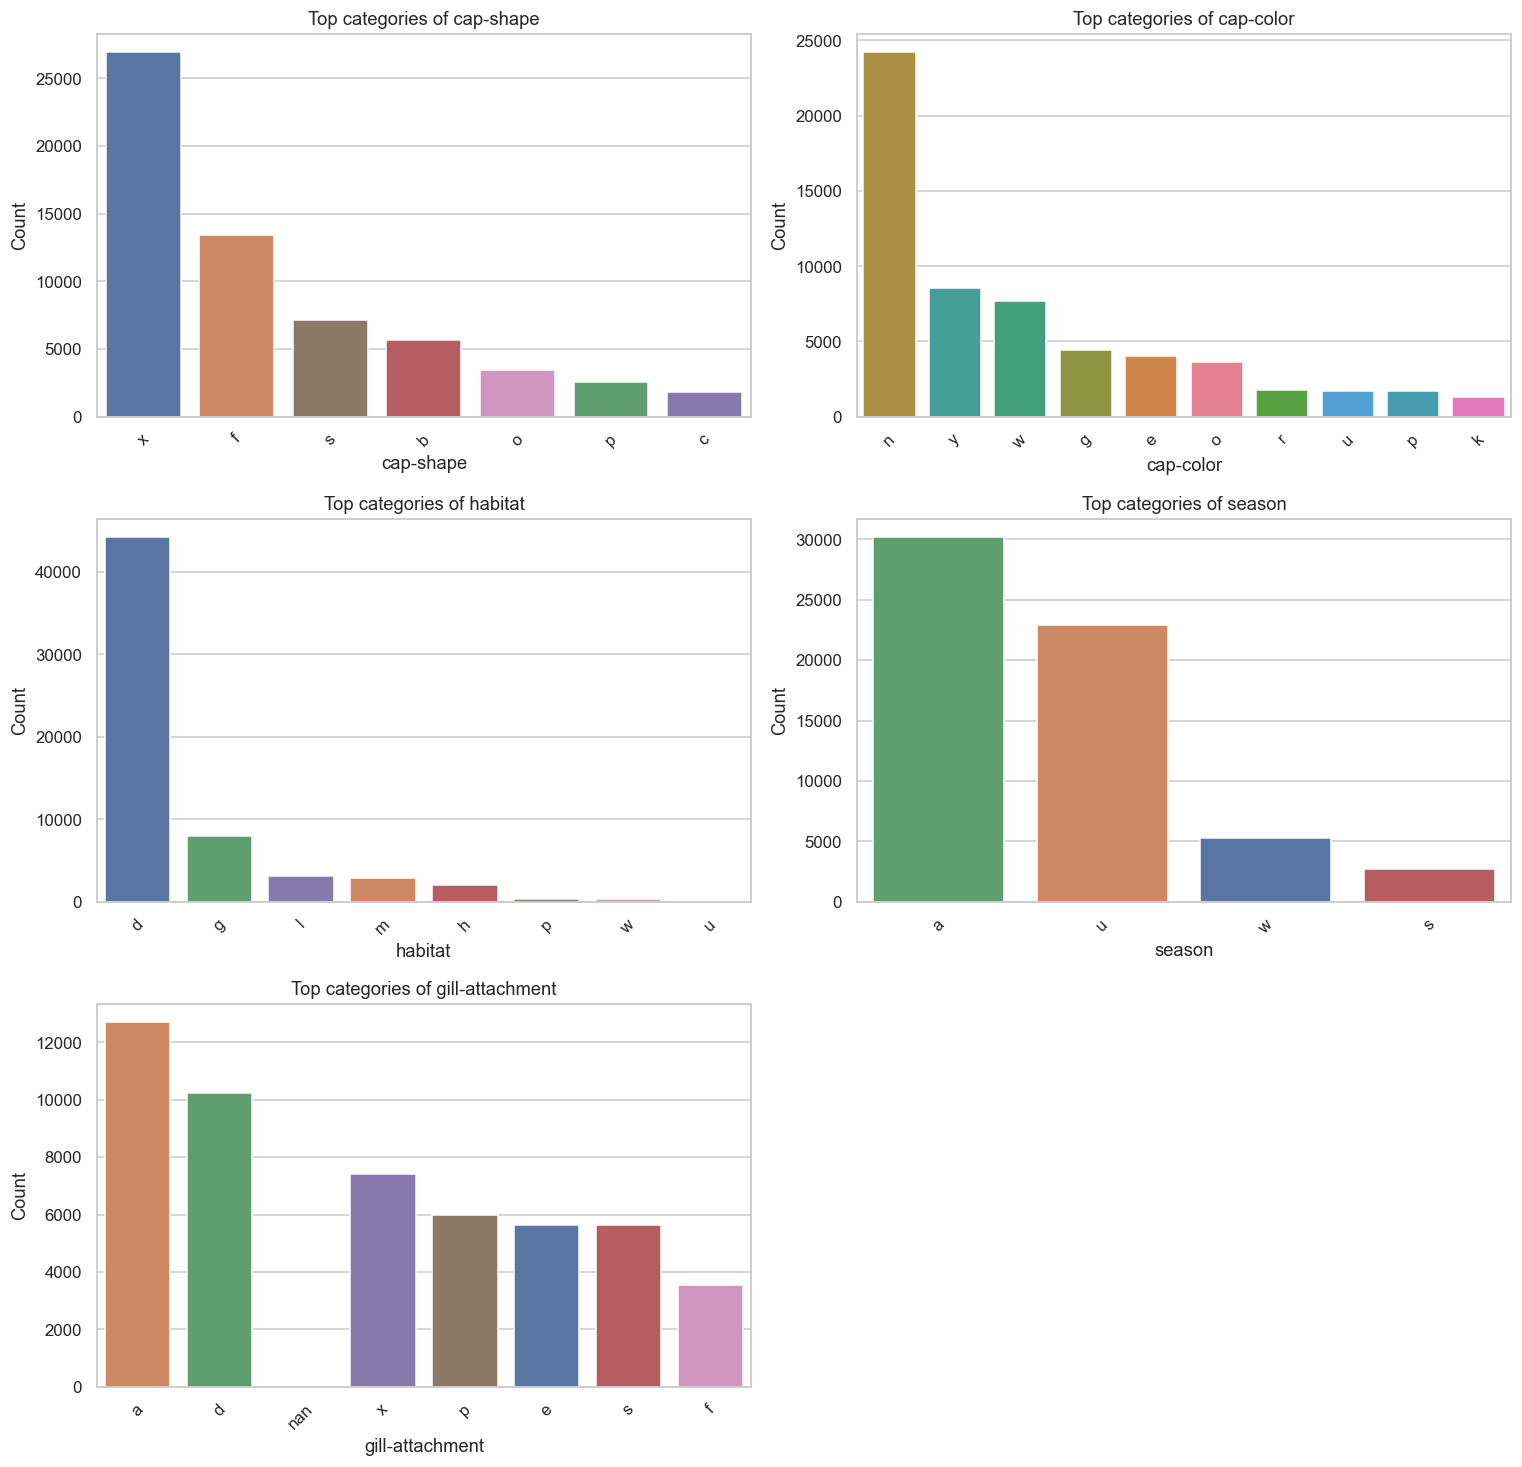

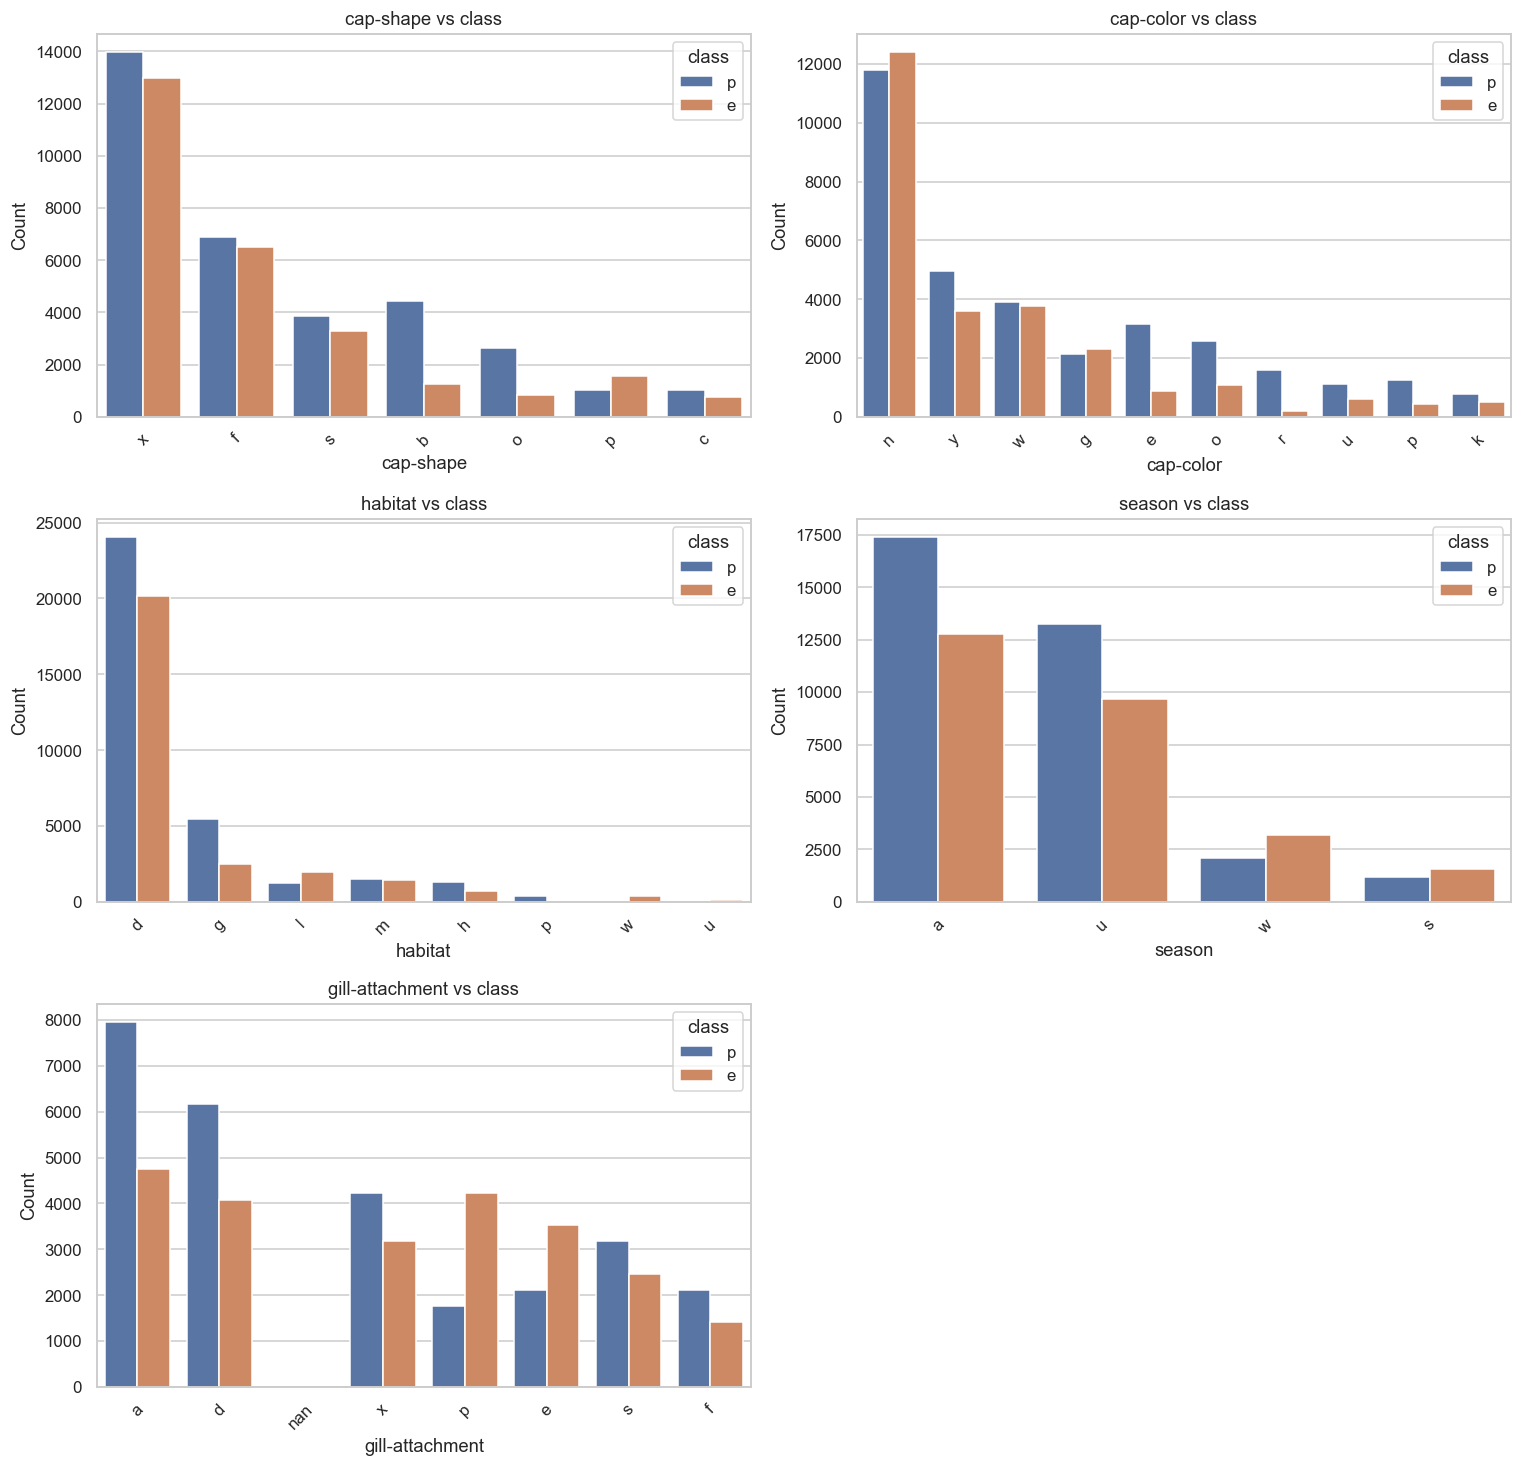

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Distribuciones de variables numéricas
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# ============================
# Boxplots por variable objetivo
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x=TARGET_COL, y=col, hue=TARGET_COL, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"{col} by {TARGET_COL}")
        axes[i].set_xlabel(TARGET_COL)
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns available for boxplots.")


# ============================
# Selección de variables categóricas a visualizar
# ============================
selected_cats = [
    "cap-shape",
    "cap-color",
    "habitat",
    "season",
    "gill-attachment",
]
selected_cats = [c for c in selected_cats if c in df.columns]


# ============================
# Top categorías por variable categórica
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, order=top_order, hue=col, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"Top categories of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found in the dataset.")


# ============================
# Variables categóricas vs variable objetivo
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, hue=TARGET_COL, order=top_order, ax=axes[i])
        axes[i].set_title(f"{col} vs {TARGET_COL}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found for target comparison.")

## 12. Análisis de Correlación

El análisis de correlación se centra en las variables numéricas del dataset.  
Esto nos ayuda a identificar si algunas características están relacionadas linealmente y si puede existir redundancia o dependencia entre ellas.

Se incluye un mapa de calor de correlación para facilitar la interpretación.

,cap-diameter,stem-height,stem-width
cap-diameter,1.00000,0.422560,0.695330
stem-height,0.42256,1.000000,0.436117
stem-width,0.69533,0.436117,1.000000


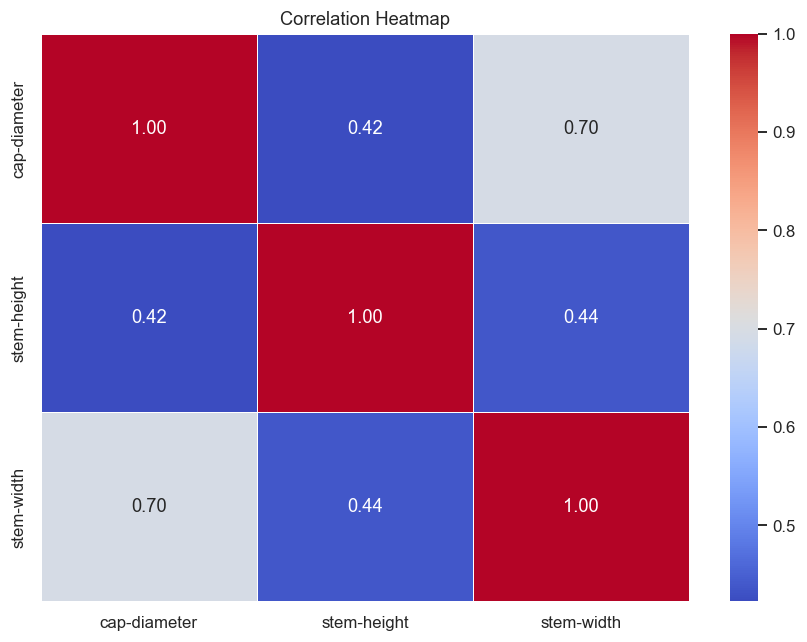

In [11]:
# ============================
# Matriz de correlación
# ============================
corr = df[numerical_cols].corr(method="pearson", numeric_only=True)
display(corr)

# ============================
# Heatmap de correlación
# ============================
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Observamos una relación entre las variables 'stem-width' y 'cap-diameter' de acuerdo a su índice de correlación de 0.70

## 13. Principales Hallazgos

Con base en el análisis exploratorio, esta sección resume los hallazgos más importantes relacionados con:

la distribución de clases,
las variables relevantes,
los valores faltantes,
las categorías inusuales,
los valores atípicos,
y las posibles implicaciones para futuros flujos de trabajo de aprendizaje automático.


In [12]:
import numpy as np

def _fmt_pct(x: float) -> str:
    return f"{x:.2f}%"

n_rows, n_cols = df.shape
n_miss = int(df.isna().sum().sum())
n_dup = int(df.duplicated().sum())

vc = df[TARGET_COL].value_counts(normalize=True) * 100
p_pct = float(vc.get("p", np.nan))
e_pct = float(vc.get("e", np.nan))

outlier_lines = []
if not iqr_outliers.empty:
    for _, r in iqr_outliers.iterrows():
        outlier_lines.append(
            f"  - {r['column']}: {int(r['outlier_count'])} rows ({r['outlier_percent']:.2f}%) beyond 1.5×IQR fences"
        )
else:
    outlier_lines.append("  - No numerical columns or no IQR summary computed.")

corr_high = []
if len(numerical_cols) >= 2:
    c = df[numerical_cols].corr(numeric_only=True)
    for i, a in enumerate(numerical_cols):
        for b in numerical_cols[i + 1:]:
            val = c.loc[a, b]
            if abs(val) >= 0.7:
                corr_high.append(f"{a} vs {b}: {val:.3f}")

print("EDA concise summary (Secondary Mushroom Dataset)")
print("=" * 60)
print(f"Rows: {n_rows:,} | Features (total columns): {n_cols}")
print(f"Missing values (cell-level): {n_miss:,}")
print(f"Fully duplicated rows: {n_dup:,}")
print(f"Numerical features: {numerical_cols}")

if pd.notna(p_pct) and pd.notna(e_pct):
    print(f"Target balance ({TARGET_COL}): p={_fmt_pct(p_pct)}, e={_fmt_pct(e_pct)}")
else:
    print(f"Target balance: {vc.to_dict()}")

print("IQR-based outliers (1.5×IQR):")
print("\n".join(outlier_lines))

if corr_high:
    print("Strong linear correlations (|r| ≥ 0.7):")
    for line in corr_high:
        print("  -", line)
else:
    print("Strong linear correlations (|r| ≥ 0.7): none detected among current numerical features.")

print("=" * 60)
print("Next steps (Part II): preprocessing pipeline, encoding, baseline model, tracking, evaluation.")


EDA concise summary (Secondary Mushroom Dataset)
Rows: 61,069 | Features (total columns): 21
Missing values (cell-level): 307,463
Fully duplicated rows: 146
Numerical features: ['cap-diameter', 'stem-height', 'stem-width']
Target balance (class): p=55.49%, e=44.51%
IQR-based outliers (1.5×IQR):
  - cap-diameter: 2400 rows (3.93%) beyond 1.5×IQR fences
  - stem-height: 3169 rows (5.19%) beyond 1.5×IQR fences
  - stem-width: 1967 rows (3.22%) beyond 1.5×IQR fences
Strong linear correlations (|r| ≥ 0.7): none detected among current numerical features.
Next steps (Part II): preprocessing pipeline, encoding, baseline model, tracking, evaluation.


## Continuación del proyecto — Limpieza, modelado y evaluación

Las siguientes celdas **no modifican** el EDA anterior: asumen que `df`, `TARGET_COL`, `PROJECT_ROOT` y `DATA_PATH` ya existen por la ejecución secuencial del cuaderno.

Se prioriza **evitar fuga de información** (p. ej., SMOTE **solo** en entrenamiento dentro de un `Pipeline` de `imblearn`).

El código está estructurado con constantes y funciones pequeñas para facilitar su envoltura futura con **MLflow** (métricas/params/artifacts) y **Prefect** (flujos y tareas).


### 1. Limpieza de datos


In [13]:
# Dependencias para balanceo (SMOTE). Si falla el import, instalar en el mismo kernel:
# pip install imbalanced-learn
try:
    import imblearn  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"]
    )

import numpy as np
import pandas as pd
from IPython.display import display

# --- Reproducibilidad y metadatos útiles para MLflow/Prefect ---
RANDOM_STATE = 42
EXPERIMENT_NAME = "mushroom_secondary_classification"
PRIMARY_METRIC = "f1_venenoso"  # positivo = venenoso (1)

# Copia explícita: no mutar el DataFrame del EDA si se re-ejecutan secciones fuera de orden.
ml_df = df.copy()

print("Shape inicial (copia para modelado):", ml_df.shape)


Shape inicial (copia para modelado): (61069, 21)


In [14]:
# ---------------------------------------------------------------------------
# 1.a) Filas duplicadas (exactas, todas las columnas)
# Decisión: los duplicados completos no aportan nuevas combinaciones (X, y); solo
# repiten el mismo ejemplo y pueden inflar artificialmente la confianza del modelo.
# Verificamos:
#   - Cuántos hay y el cambio de proporción de clases al eliminarlos.
#   - Si existiera la misma X con distinta y, sería un problema de calidad; eso NO
#     se corrige con drop_duplicates() sobre la fila completa (aquí solo quitamos
#     filas idénticas incluyendo la etiqueta).
# ---------------------------------------------------------------------------
TARGET = TARGET_COL

def class_balance(frame: pd.DataFrame, col: str) -> pd.Series:
    return frame[col].value_counts(normalize=True, dropna=False).sort_index()

n_dup_exact = int(ml_df.duplicated().sum())
print(f"Filas duplicadas exactas (todas las columnas) a eliminar si procede: {n_dup_exact:,}")

# Nota: duplicados de *fila completa* incluyen la etiqueta; no eliminamos el único
# representante de un patrón X. Si existieran X idénticas con y distinta, habría que
# auditarlas aparte (tarea de calidad de datos), no con drop_duplicates() simple.

bal_before = class_balance(ml_df, TARGET)
print("Balance de clases antes de drop_duplicates:", bal_before.to_dict())

ml_df_nodup = ml_df.drop_duplicates()
bal_after = class_balance(ml_df_nodup, TARGET)
delta = (bal_after - bal_before).abs().max()
print("Balance de clases después:", bal_after.to_dict())
print(f"Máx. |Δ proporción| por clase: {delta:.6f}")

# Regla conservadora: si el cambio de balance es despreciable, eliminamos duplicados.
# (Si fuera grande, mantendríamos duplicados para no alterar el muestreo observado.)
if delta <= 0.02:
    print(f"Se eliminan {len(ml_df) - len(ml_df_nodup):,} filas duplicadas exactas.")
    ml_df = ml_df_nodup.reset_index(drop=True)
else:
    print("Cambio de balance > 2%: NO se eliminan duplicados (conservar distribución observada).")

print("Shape tras decisión de duplicados:", ml_df.shape)


Filas duplicadas exactas (todas las columnas) a eliminar si procede: 146
Balance de clases antes de drop_duplicates: {'e': 0.44508670520231214, 'p': 0.5549132947976878}
Balance de clases después: {'e': 0.44615334110270344, 'p': 0.5538466588972966}
Máx. |Δ proporción| por clase: 0.001067
Se eliminan 146 filas duplicadas exactas.
Shape tras decisión de duplicados: (60923, 21)


In [15]:
# ---------------------------------------------------------------------------
# 1.b) Codificación de valores desconocidos como NaN
# En UCI/secondary mushroom, '?' suele representar desconocido. Lo normalizamos a NaN
# para poder contar y tratar faltantes de forma explícita.
# ---------------------------------------------------------------------------
ml_df = ml_df.replace(r"^\s*\?\s*$", np.nan, regex=True)
# Por si hubiera '?' sin regex en strings simples:
ml_df = ml_df.replace("?", np.nan)

missing_per_col = ml_df.isna().sum().sort_values(ascending=False)
missing_tbl = (
    missing_per_col[missing_per_col > 0]
    .to_frame("n_missing")
    .assign(pct=lambda t: (100 * t["n_missing"] / len(ml_df)).round(3))
)
print("Columnas con valores faltantes (post-'?'):")
display(missing_tbl if not missing_tbl.empty else pd.DataFrame({"info": ["sin NaN"]}))

# ---------------------------------------------------------------------------
# 1.c) Valores faltantes: eliminación vs imputación
# Regla práctica: si `dropna(how="any")` deja un conjunto razonable, eliminamos filas
# incompletas (caso ideal del enunciado). En este dataset, los faltantes son masivos
# y coexisten en casi todas las filas: la eliminación listwise vaciaría el corpus.
# Por tanto **no aplicamos dropna global** y delegamos la imputación al Pipeline
# (mediana / moda calculadas solo con el train → sin leakage).
# ---------------------------------------------------------------------------
rows_before = len(ml_df)
complete_mask = ~ml_df.isna().any(axis=1)
n_complete = int(complete_mask.sum())
print(f"Filas sin ningún NaN (caso completo): {n_complete:,} de {rows_before:,}")

if n_complete >= 0.5 * rows_before:
    ml_df = ml_df.loc[complete_mask].reset_index(drop=True)
    print("Se aplicó dropna: al menos el 50% de filas permanecía completo.")
else:
    print(
        "No se aplica dropna global (destruiría casi todo el dataset). "
        "La imputación ocurre en el preprocesamiento del modelo (sección 3)."
    )

# Si el target tuviera NaN, sí conviene descartar esas filas (no aprendibles).
bad_target = ml_df[TARGET].isna()
if bad_target.any():
    n_bt = int(bad_target.sum())
    ml_df = ml_df.loc[~bad_target].reset_index(drop=True)
    print(f"Filas eliminadas por etiqueta {TARGET} ausente: {n_bt:,}")

print("Shape final tras limpieza:", ml_df.shape)


Columnas con valores faltantes (post-'?'):


,n_missing,pct
veil-type,57746,94.785
spore-print-color,54597,89.616
veil-color,53510,87.832
stem-root,51536,84.592
stem-surface,38122,62.574
gill-spacing,25062,41.137
cap-surface,14120,23.177
gill-attachment,9855,16.176
ring-type,2471,4.056


Filas sin ningún NaN (caso completo): 0 de 60,923
No se aplica dropna global (destruiría casi todo el dataset). La imputación ocurre en el preprocesamiento del modelo (sección 3).
Shape final tras limpieza: (60923, 21)


### 2. Preparación de datos


In [16]:
from sklearn.model_selection import train_test_split

X = ml_df.drop(columns=[TARGET]).copy()
y = ml_df[TARGET].map({"p": 1, "e": 0})
if y.isna().any():
    raise ValueError("Existen etiquetas fuera de {'p','e'} tras la limpieza.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución y (train):")
print(y_train.value_counts(normalize=True))
print("Distribución y (test):")
print(y_test.value_counts(normalize=True))


Train: (48738, 20) Test: (12185, 20)
Distribución y (train):
class
1    0.553839
0    0.446161
Name: proportion, dtype: float64
Distribución y (test):
class
1    0.553878
0    0.446122
Name: proportion, dtype: float64


### 3. Transformación de características

Los modelos lineales, ensambles basados en divisiones de umbral, etc., operan sobre **números**. Las variables categóricas en texto **no tienen orden natural**; asignarles números arbitrarios introduce un orden falso. **One-Hot Encoding** crea columnas binarias por categoría, preservando la naturaleza nominal y permitiendo que el modelo aprenda pesos independientes por nivel.

Usamos `ColumnTransformer` para aplicar transformaciones distintas por tipo de columna en un solo objeto reutilizable (ideal para `Pipeline` y serialización).

Dado el volumen de faltantes, añadimos **`SimpleImputer`** (mediana en numéricas, categoría más frecuente en categóricas) **dentro** de los sub-pipelines, de modo que los estadísticos se aprenden solo con el conjunto de entrenamiento al hacer `fit` del `Pipeline` completo.


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

# OneHotEncoder: matriz densa para SMOTE y GradientBoosting "clásico".
try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:  # sklearn < 1.2
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# SimpleImputer dentro de sub-pipelines: estadísticos se aprenden solo en train.
num_pipe = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
cat_pipe = SkPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", _ohe),
    ]
)

if numeric_features:
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipe, numeric_features),
            ("cat", cat_pipe, categorical_features),
        ],
        remainder="drop",
    )
else:
    preprocessor = ColumnTransformer(
        transformers=[("cat", cat_pipe, categorical_features)],
        remainder="drop",
    )

# Cabe ajustar solo en train dentro del Pipeline global (evita leakage).


Numéricas: ['cap-diameter', 'stem-height', 'stem-width']
Categóricas: ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


### 4. Balanceo de datos con SMOTE (solo entrenamiento)

**SMOTE** (Synthetic Minority Over-sampling Technique) genera ejemplos sintéticos de la clase minoritaria interpolando vecinos en el espacio de características **ya transformadas** (numéricas). Sirve para mitigar el sesgo hacia la clase mayoritaria cuando métricas como el **recall** de la clase venenosa importan.

Lo integramos en un `imblearn.pipeline.Pipeline` **después** del preprocesamiento y **solo** durante `fit` sobre train; en predicción sobre test **no** se generan sintéticos, evitando **data leakage**.


In [18]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE sobre matriz densa post-OHE (+ escalado numérico)
smote = SMOTE(random_state=RANDOM_STATE)


def build_modeling_pipeline(classifier) -> ImbPipeline:
    # Preprocesamiento -> SMOTE (solo en fit/train) -> clasificador
    return ImbPipeline(
        steps=[
            ("preprocess", preprocessor),
            ("smote", smote),
            ("clf", classifier),
        ]
    )


### 5. Modelos de Machine Learning

Para cada estimador se define un `ImbPipeline` con el mismo preprocesamiento y SMOTE; se entrena con el train balanceado internamente y se evalúa en el test **sin** tocar el test en el balanceo.


In [19]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

try:
    from xgboost import XGBClassifier

    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False

MODEL_SPECS = {
    "LogisticRegression (baseline)": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight=None,  # el balanceo principal lo aporta SMOTE en train
        solver="lbfgs",
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight=None,
        n_jobs=-1,
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

if _HAS_XGB:
    MODEL_SPECS["XGBClassifier"] = XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=6,
        eval_metric="logloss",
        n_jobs=-1,
    )

fitted_models = {}
test_predictions = {}

for name, clf in MODEL_SPECS.items():
    pipe = build_modeling_pipeline(clf)
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    test_predictions[name] = pipe.predict(X_test)

print("Modelos entrenados:", list(fitted_models.keys()))


Modelos entrenados: ['LogisticRegression (baseline)', 'RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier']


### 6. Evaluación

Usamos `classification_report` para visión por clase y el **F1-score** binario con `pos_label=1` (venenoso).

**¿Por qué importa el F1?** En problemas de seguridad con clases desbalanceadas, ni la precisión ni el recall por sí solos cuentan toda la historia: puedes obtener alta precisión ignorando venenosos raros. El **F1** balancea precisión y recall y es una métrica estable para comparar modelos cuando ambos errores importan.

**Recall de la clase venenosa (1):** un falso negativo (predecir comestible cuando es venenoso) puede ser **peligroso**; por eso priorizamos un **recall alto** para la clase `1`, sin descuidar del todo la precisión para no generar demasiadas falsas alarmas.


In [20]:
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support

rows = []
label_names = ["comestible e (0)", "venenoso p (1)"]

for name, y_pred in test_predictions.items():
    print("\n" + "=" * 80)
    print(name)
    print(classification_report(y_test, y_pred, target_names=label_names, digits=4))
    f1_poison = f1_score(y_test, y_pred, pos_label=1, average="binary")
    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", pos_label=1, zero_division=0
    )
    rows.append(
        {
            "modelo": name,
            "precision_venenoso": p,
            "recall_venenoso": r,
            "f1_venenoso": f1_poison,
        }
    )

results_df = pd.DataFrame(rows).sort_values("f1_venenoso", ascending=False).reset_index(drop=True)
display(results_df)



LogisticRegression (baseline)
                  precision    recall  f1-score   support

comestible e (0)     0.8033    0.8637    0.8324      5436
  venenoso p (1)     0.8831    0.8296    0.8555      6749

        accuracy                         0.8448     12185
       macro avg     0.8432    0.8466    0.8440     12185
    weighted avg     0.8475    0.8448    0.8452     12185


RandomForestClassifier
                  precision    recall  f1-score   support

comestible e (0)     1.0000    1.0000    1.0000      5436
  venenoso p (1)     1.0000    1.0000    1.0000      6749

        accuracy                         1.0000     12185
       macro avg     1.0000    1.0000    1.0000     12185
    weighted avg     1.0000    1.0000    1.0000     12185


GradientBoostingClassifier
                  precision    recall  f1-score   support

comestible e (0)     0.8923    0.9678    0.9285      5436
  venenoso p (1)     0.9722    0.9059    0.9379      6749

        accuracy                       

,modelo,precision_venenoso,recall_venenoso,f1_venenoso
0,RandomForestClassifier,1.000000,1.000000,1.000000
1,XGBClassifier,1.000000,1.000000,1.000000
2,GradientBoostingClassifier,0.972174,0.905912,0.937874
3,LogisticRegression (baseline),0.883123,0.829604,0.855528


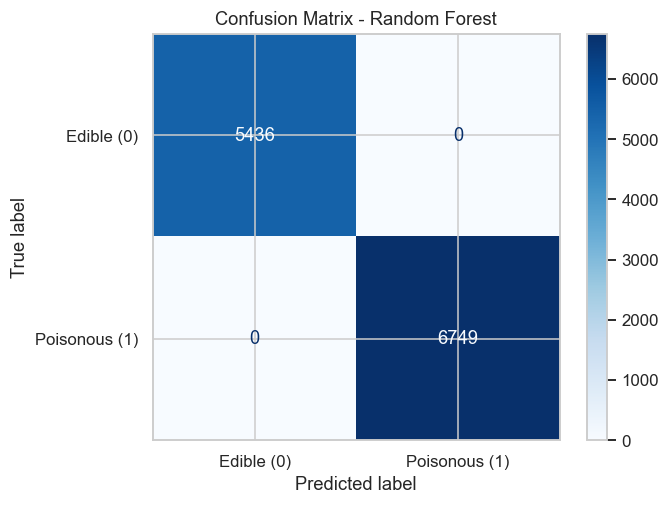

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Edible (0)", "Poisonous (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### 7. Comparación de resultados y mejor modelo


In [21]:
best = results_df.iloc[0]
msg = (
    "Mejor modelo según F1 de la clase venenosa (pos_label=1): %s | F1=%.4f, Recall=%.4f, Precision=%.4f"
    % (
        best["modelo"],
        best["f1_venenoso"],
        best["recall_venenoso"],
        best["precision_venenoso"],
    )
)
print(msg)


Mejor modelo según F1 de la clase venenosa (pos_label=1): RandomForestClassifier | F1=1.0000, Recall=1.0000, Precision=1.0000


### 8. Modelo candidato a producción

Seleccionamos el modelo con mayor **F1-score para venenoso (1)** en el conjunto de prueba, alineado con el objetivo de reducir falsos negativos sin colapsar la precisión.

**Candidato a producción:** suele ser un modelo con buen equilibrio, comportamiento estable y coste computacional razonable en inferencia. `RandomForest` y `GradientBoosting` suelen ser robustos en datos tabulares; la regresión logística aporta un **baseline** interpretable y rápido.

**Integración futura (MLflow / Prefect):** encapsular `DATA_PATH`, `RANDOM_STATE`, nombres de experimentos y el `ImbPipeline` final en una función de entrenamiento; registrar hiperparámetros (`mlflow.log_params`), métricas (`mlflow.log_metrics`) y el artefacto del modelo (`mlflow.sklearn.log_model`). En Prefect, separar tareas: `load_data`, `clean`, `split`, `train`, `evaluate`, con retries y logs estructurados.


In [22]:
best_name = str(best["modelo"])
production_candidate = fitted_models[best_name]

# Ejemplo de hooks futuros (comentados):
# import mlflow
# mlflow.set_experiment(EXPERIMENT_NAME)
# with mlflow.start_run(run_name=best_name):
#     mlflow.log_param("random_state", RANDOM_STATE)
#     mlflow.log_metrics(
#         {
#             "f1_venenoso": float(best["f1_venenoso"]),
#             "recall_venenoso": float(best["recall_venenoso"]),
#             "precision_venenoso": float(best["precision_venenoso"]),
#         }
#     )
#     mlflow.sklearn.log_model(production_candidate, artifact_path="model")

print("Pipeline candidato (objeto en memoria):", best_name)
print(production_candidate)


Pipeline candidato (objeto en memoria): RandomForestClassifier
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cap-diameter',
                                                   'stem-height',
                                                   'stem-width']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                            

Con base en las métricas obtenidas, se selecciona el pipeline con mejor desempeño como candidato a producción.
La integración formal con MLflow se realizará posteriormente desde el entorno de desarrollo en VSCode, como parte de la orquestación del pipeline.